<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/Practica27_263150.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Práctica 27: Validación, evaluación y selección**
---

Alumno: Álvaro Hernandez Jarquín<br>
Seminario: Programación para analítica descriptiva y predictiva

# Objetivo:
Aplicar de forma integral el proceso de **entrenamiento, ajuste y evaluación** de un **clasificador tipo Árbol de Decisión** sobre un conjunto de datos grande, aplicando técnicas robustas de validación cruzada y optimización de hiperparámetros.

📦 Dataset sugerido
Usa el conjunto de datos Glioma Grading Clinical and Mutation Features. Este conjunto de datos lo puedes encontrar en https://archive.ics.uci.edu/dataset/759/glioma+grading+clinical+and+mutation+features+dataset

# 1. Carga de bibliotecas, conjunto de datos y análisis exploratorio de los datos

* Declarar las bibliotecas necesarias para este proyecto
* Cargar el conjunto de datos Glioma Grading Clinical and Mutation Features. Se puede descargar de
`https://archive.ics.uci.edu/dataset/759/glioma+grading+clinical+and+mutation+features+dataset`

In [36]:
# Declarar las bibliotecas necesarias para este proyecto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

# Cargar el conjunto de datos Glioma Grading Clinical and Mutation Features
gliomaGrade = pd.read_csv('/content/drive/MyDrive/ClassFiles/TCGA_InfoWithGrade.csv')

:❗❗❗
  En la dirección proporcionada existían dos bases de datos:
  * **TCGA_InfoWithGrade** o
  * TCGA_GBM_LGG_Mutations_all <br>
  y se seleccionó el primero porque tiene los datos ordenados y en números

# 2. 📊 Análisis exploratorio de datos (EDA)

Realiza un análisis inicial de los datos antes de modelar:

* Describir forma y estructura (shape, describe(), info()).

* Mostrar la distribución de clases (y.value_counts()).

* Visualizar:

  * Histograma de al menos 3 variables numéricas.

  * Boxplots o violin plots por clase si es computacionalmente viable.

  * Mapa de calor de correlaciones entre variables.

🧠 Reflexiona:

¿Existen clases desbalanceadas?

¿Qué atributos parecen más informativos?

In [ ]:
# Describir forma y estructura (shape, describe(), info()).
print("="*70)
print(f"Dimensiones del dataset: {gliomaGrade.shape}")
print("="*70)
print(f"Descripción del dataset:\n {gliomaGrade.describe()}")
print("="*70)
print("Información del dataset:")
gliomaGrade.info()
print("="*70)

Dimensiones del dataset: (839, 24)
Descripción del dataset:
             Grade      Gender  Age_at_diagnosis        Race        IDH1  \
count  839.000000  839.000000        839.000000  839.000000  839.000000   
mean     0.419547    0.418355         50.935411    0.107271    0.481526   
std      0.493779    0.493583         15.702339    0.369392    0.499957   
min      0.000000    0.000000         14.420000    0.000000    0.000000   
25%      0.000000    0.000000         38.055000    0.000000    0.000000   
50%      0.000000    0.000000         51.550000    0.000000    0.000000   
75%      1.000000    1.000000         62.800000    0.000000    1.000000   
max      1.000000    1.000000         89.290000    3.000000    1.000000   

             TP53        ATRX        PTEN        EGFR         CIC  ...  \
count  839.000000  839.000000  839.000000  839.000000  839.000000  ...   
mean     0.414779    0.258641    0.168057    0.133492    0.132300  ...   
std      0.492978    0.438149    0.374140

In [ ]:
# Mostrar la distribución de clases (y.value_counts()).
print("Distribución de clases:")
print(gliomaGrade['Grade'].value_counts())

Distribución de clases:
Grade
0    487
1    352
Name: count, dtype: int64


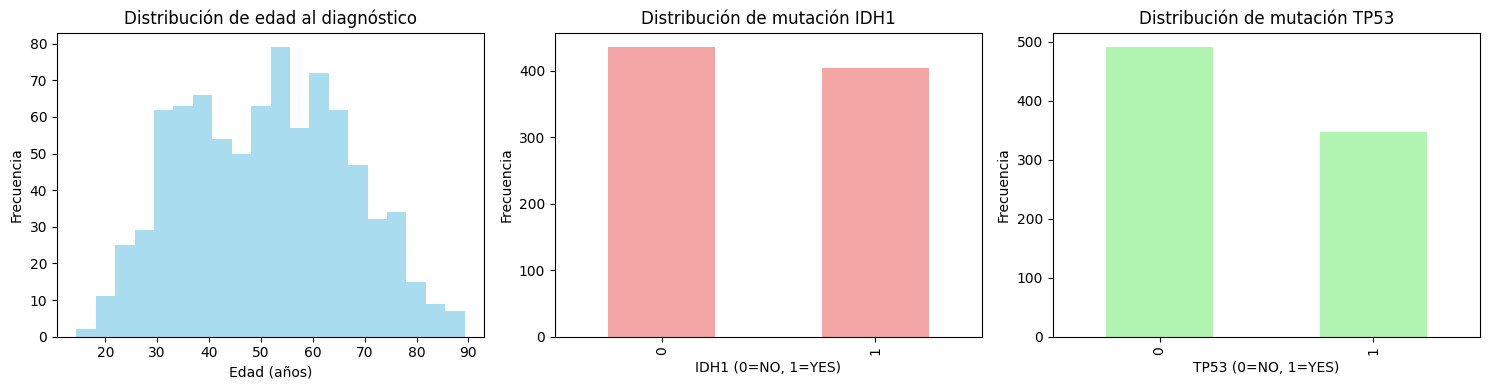

In [ ]:
# Histogramas de 3 variables numéricas
plt.figure(figsize=(15, 4))

# Histograma 1: Age_at_diagnosis
plt.subplot(1, 3, 1)
plt.hist(gliomaGrade['Age_at_diagnosis'], bins=20, color='skyblue', alpha=0.7)
plt.title('Distribución de edad al diagnóstico')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')

# Histograma 2: IDH1_num (mutaciones)
plt.subplot(1, 3, 2)
gliomaGrade['IDH1'].value_counts().sort_index().plot(kind='bar', color='lightcoral', alpha=0.7)
plt.title('Distribución de mutación IDH1')
plt.xlabel('IDH1 (0=NO, 1=YES)')
plt.ylabel('Frecuencia')

# Histograma 3: TP53_num (mutaciones)
plt.subplot(1, 3, 3)
gliomaGrade['TP53'].value_counts().sort_index().plot(kind='bar', color='lightgreen', alpha=0.7)
plt.title('Distribución de mutación TP53')
plt.xlabel('TP53 (0=NO, 1=YES)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

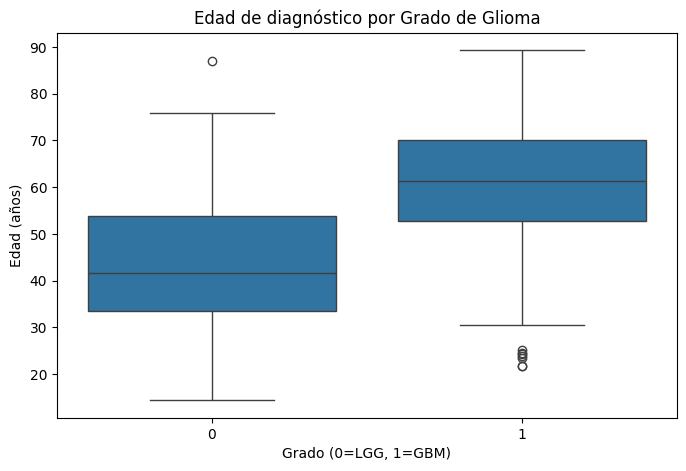

In [ ]:
# Boxplots o violin plots por clase si es computacionalmente viable.
plt.figure(figsize=(8, 5))
sns.boxplot(x='Grade', y='Age_at_diagnosis', data=gliomaGrade)
plt.title('Edad de diagnóstico por Grado de Glioma')
plt.xlabel('Grado (0=LGG, 1=GBM)')
plt.ylabel('Edad (años)')
plt.show()

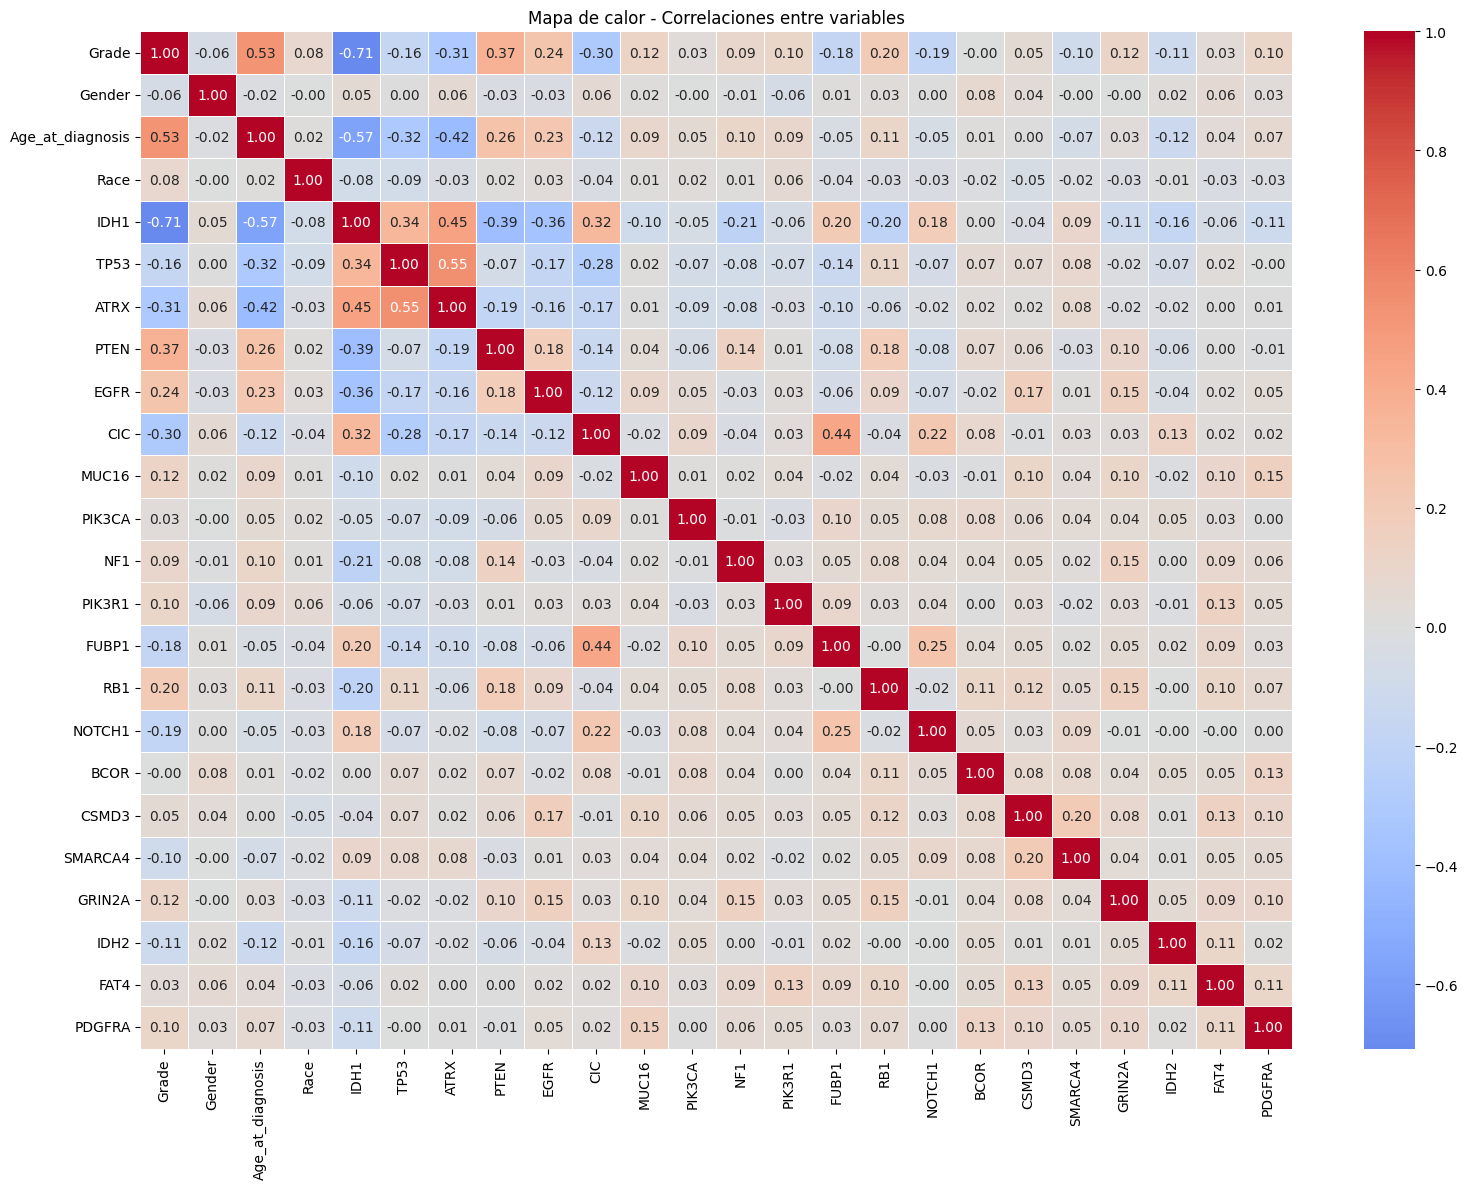

In [33]:
# Mapa de calor de correlaciones entre variables.
plt.figure(figsize=(16, 12))

# Calcular matriz de correlación
correlation_matrix = gliomaGrade.corr()

# Crear heatmap
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f',
            linewidths=0.5)
plt.title('Mapa de calor - Correlaciones entre variables')
plt.tight_layout()
plt.show()

🧠 Reflexiona:

¿Existen clases desbalanceadas? <br>
Existe un desbalance moderado LGG: 487 muestras (58.04%) y GBM: 352 muestras (41.95%).
¿Qué atributos parecen más informativos? <br>
IDH1 tiene una correlación negativa muy fuerte -0.71 y Age_at_diagnosis tiene fuerte correlación positiva: 0.53, PTEN tiene correlación de 0.37 y ATRX de -0.31.

# 3. Gráfica de Errores en Entrenamiento y Prueba

* En este ejercicio vas a entrenar un árbol de decisión con diferentes profundidades. Asimismo, en gráfica mostrarás las exactitudes en entrenamiento y test, usando un stratified k-fold cross-validation con K= 10
* Los valores de las profundidades a evaluar son 2, 5, 10, 15, 20, 25, 30 y None
* Deberás usar StratifiedKFold con 10 particiones, y un valor aleatorio de 3
* Entrenarás y evaluarás un árbol de decisión con estos distintos valores de profundidades
* Usa cross_val_score para entrenar los modelos, usando como métrica de evaluación en scoring ="f1_macro",y el StratifiedKFold, con un valor aleatorio = 7
* Muestra una gráfica para los distintos resultados  cuando se usa F1 Macro

In [ ]:
# Definir X e y
X = gliomaGrade.drop('Grade', axis=1)
y = gliomaGrade['Grade']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Columnas en X: {X.columns.tolist()}")

X shape: (839, 23)
y shape: (839,)
Columnas en X: ['Gender', 'Age_at_diagnosis', 'Race', 'IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA', 'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1', 'BCOR', 'CSMD3', 'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']


Profundidad 2: F1 Macro TEST = 0.8665, F1 Macro TRAIN = 0.8691
Profundidad 5: F1 Macro TEST = 0.8565, F1 Macro TRAIN = 0.8857
Profundidad 10: F1 Macro TEST = 0.8225, F1 Macro TRAIN = 0.9286
Profundidad 15: F1 Macro TEST = 0.7899, F1 Macro TRAIN = 0.9756
Profundidad 20: F1 Macro TEST = 0.7979, F1 Macro TRAIN = 0.9953
Profundidad 25: F1 Macro TEST = 0.7987, F1 Macro TRAIN = 0.9989
Profundidad 30: F1 Macro TEST = 0.7948, F1 Macro TRAIN = 1.0000
Profundidad None: F1 Macro TEST = 0.7948, F1 Macro TRAIN = 1.0000


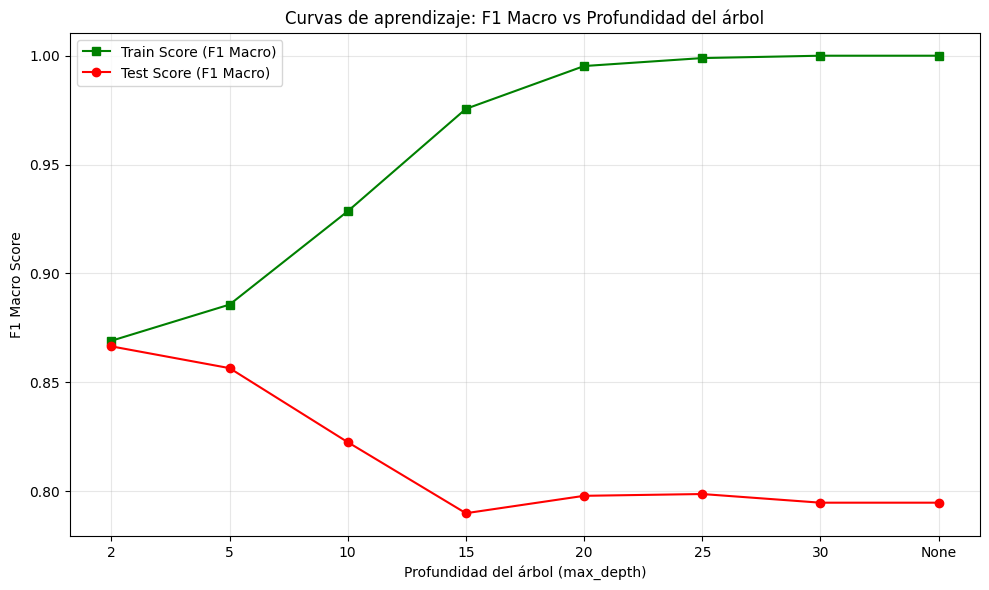

In [38]:
# Entrenar un árbol de decisión con diferentes profundidades.
# Los valores de las profundidades a evaluar son 2, 5, 10, 15, 20, 25, 30 y None
profundidades = [2, 5, 10, 15, 20, 25, 30, None]

# Usar StratifiedKFold con 10 particiones, y un valor aleatorio de 3
kfold_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=3)
train_scores = []
test_scores_f1 = []

# Usa cross_val_score para entrenar los modelos,
# usando como métrica de evaluación en scoring ="f1_macro",
# y el StratifiedKFold, con un valor aleatorio = 7
for depth in profundidades:
    arbol = DecisionTreeClassifier(max_depth=depth, random_state=7)

    cv_results = cross_validate(
        arbol, X, y, cv=kfold_cv,
        scoring='f1_macro',
        return_train_score=True,
        n_jobs=-1
    )

    train_scores.append(cv_results['train_score'].mean())
    test_scores_f1.append(cv_results['test_score'].mean())
    print(f"Profundidad {depth}: F1 Macro TEST = {cv_results['test_score'].mean():.4f}, F1 Macro TRAIN = {cv_results['train_score'].mean():.4f}")

# Muestra una gráfica para los distintos resultados cuando se usa F1 Macro
plt.figure(figsize=(10, 6))
prof_labels = [str(p) for p in profundidades]

# Curva de entrenamiento
plt.plot(prof_labels, train_scores, marker='s', label='Train Score (F1 Macro)', color='green')
# Curva de prueba
plt.plot(prof_labels, test_scores_f1, marker='o', label='Test Score (F1 Macro)', color='red')

plt.title('Curvas de aprendizaje: F1 Macro vs Profundidad del árbol')
plt.xlabel('Profundidad del árbol (max_depth)')
plt.ylabel('F1 Macro Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Optimización de hiperparámetros con RandomizedSearchCV

* Define el espacio de búsqueda aleatorio para los siguientes hiperpárametros:
  * Criterion = gini ,entropy
  * max_depth: de 5 a 50 con incrementos de 1
  * min_samples_split: de 2 a 20 con incrementos de 1
* Usa el árbol de decisión
* StratifiedKfold = 10 (no deberás realizar ninguna partición previa: realiza el ejercicio considerando que es un conjunto de tamaño medio)
* n_iter = 5 (combinaciones aleatorias a buscar)
* n_jobs = -1 para acelerar cómputo
* Métrica de evaluación: f1 Macro
* Imprime los mejores hiperparámetros encontrados
* Imprime el best_score

In [39]:
# Define el espacio de búsqueda aleatorio para los siguientes hiperpárametros:
# Criterion = gini ,entropy
# max_depth: de 5 a 50 con incrementos de 1
# min_samples_split: de 2 a 20 con incrementos de 1
param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': list(range(5, 51)),
    'min_samples_split': list(range(2, 21))
}

# Usa el árbol de decisión
arbol = DecisionTreeClassifier(random_state=42)

# StratifiedKfold = 10
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# n_iter = 5 (combinaciones aleatorias a buscar)
# n_jobs = -1 para acelerar cómputo
# Métrica de evaluación: f1 Macro
random_search = RandomizedSearchCV(
    estimator=arbol,
    param_distributions=param_dist,
    n_iter=5,
    cv=kfold,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X, y)

# Imprime los mejores hiperparámetros encontrados
print("Mejores hiperparámetros encontrados:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")


# Imprime el best_score
print(f"\nBest score (F1 Macro): {random_search.best_score_:.4f}")


Mejores hiperparámetros encontrados:
  min_samples_split: 11
  max_depth: 18
  criterion: entropy

Best score (F1 Macro): 0.8318


# 5. Optimización de hiperparámetros con GridSearchCV

* Define el espacio de búsqueda  para los siguientes hiperpárametros:
    * Criterion = gini ,entropy
    * max_depth: de 5 a 50 con incrementos de 1
    * min_samples_split: de 2 a 20 con incrementos de 1
* Usa el árbol de decisión
* StratifiedKfold = 10 (no deberás realizar ninguna partición previa: realiza el ejercicio considerando que es un conjunto de tamaño medio)
* Métrica de evaluación: f1 Macro
* n_jobs = -1 para acelerar cómputo
* Imprime los mejores hiperparámetros encontrados
* Imprime el best_score

In [40]:
# Define el espacio de búsqueda para los siguientes hiperpárametros:
# Criterion = gini ,entropy
# max_depth: de 5 a 50 con incrementos de 1
# min_samples_split: de 2 a 20 con incrementos de 1
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': list(range(5, 51)),
    'min_samples_split': list(range(2, 21))
}

# Usa el árbol de decisión
arbol2 = DecisionTreeClassifier(random_state=42)

# StratifiedKfold = 10
kfold2 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Métrica de evaluación: f1 Macro
# n_jobs = -1 para acelerar cómputo
grid_search2 = GridSearchCV(
    estimator=arbol2,
    param_grid=param_grid,
    cv=kfold2,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search2.fit(X, y)

# Imprime los mejores hiperparámetros encontrados
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search2.best_params_.items():
    print(f"  {param}: {value}")

# Imprime el best_score
print(f"\nBest score (F1 Macro): {grid_search2.best_score_:.4f}")

Mejores hiperparámetros encontrados:
  criterion: entropy
  max_depth: 5
  min_samples_split: 12

Best score (F1 Macro): 0.8641


# 6. Optimización de hiperparámetros con RandomizedSearchCV: Accuracy

* Define el espacio de búsqueda aleatorio para los siguientes hiperpárametros:
    * Criterion = gini ,entropy
    * max_depth: de 5 a 50 con incrementos de 1
    * min_samples_split: de 2 a 20 con incrementos de 1
* Usa el árbol de decisión
* StratifiedKfold = 10 (no deberás realizar ninguna partición previa: * realiza el ejercicio considerando que es un conjunto de tamaño medio)
* n_iter = 5 (combinaciones aleatorias a buscar)
* n_jobs = -1 para acelerar cómputo
* Métrica de evaluación: accuracy
* Imprime los mejores hiperparámetros encontrados
* Imprime el best_score

In [ ]:
# Define el espacio de búsqueda aleatorio para los siguientes hiperpárametros:
# Criterion = gini ,entropy
# max_depth: de 5 a 50 con incrementos de 1
# min_samples_split: de 2 a 20 con incrementos de 1
param_dist_accuracy = {
    'criterion': ['gini', 'entropy'],
    'max_depth': list(range(5, 51)),
    'min_samples_split': list(range(2, 21))
}

# Usa el árbol de decisión
arbol3 = DecisionTreeClassifier(random_state=42)

# StratifiedKfold = 10
kfold3 = StratifiedKFold(n_splits=10, shuffle=True, random_state=3)

# n_iter = 5 (combinaciones aleatorias a buscar)
# n_jobs = -1 para acelerar cómputo
# Métrica de evaluación: accuracy
random_search_accuracy = RandomizedSearchCV(
    estimator=arbol3,
    param_distributions=param_dist_accuracy,
    n_iter=5,
    cv=kfold3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

random_search_accuracy.fit(X, y)

# Imprime los mejores hiperparámetros encontrados
print("Mejores hiperparámetros encontrados (Accuracy):")
for param, value in random_search_accuracy.best_params_.items():
    print(f"  {param}: {value}")

# Imprime el best_score
print(f"\nBest score (Accuracy): {random_search_accuracy.best_score_:.4f}")


Mejores hiperparámetros encontrados (Accuracy):
  min_samples_split: 17
  max_depth: 35
  criterion: entropy

Best score (Accuracy): 0.8450


# 7. Optimización de hiperparámetros con GridSearchCV: accuracy

* Define el espacio de búsqueda  para los siguientes hiperpárametros:
    * Criterion = gini ,entropy
    * max_depth: de 5 a 50 con incrementos de 1
    * min_samples_split: de 2 a 20 con incrementos de 1
* Usa el árbol de decisión
* StratifiedKfold = 10 (no deberás realizar ninguna partición previa: realiza el ejercicio considerando que es un conjunto de tamaño medio)
* Métrica de evaluación: f1 Macro
* n_jobs = -1 para acelerar cómputo
* Imprime los mejores hiperparámetros encontrados
* Imprime el best_score

In [ ]:
# Define el espacio de búsqueda para los siguientes hiperpárametros:
# Criterion = gini ,entropy
# max_depth: de 5 a 50 con incrementos de 1
# min_samples_split: de 2 a 20 con incrementos de 1
param_grid_accuracy = {
    'criterion': ['gini', 'entropy'],
    'max_depth': list(range(5, 51)),
    'min_samples_split': list(range(2, 21))
}

# Usa el árbol de decisión
arbol4 = DecisionTreeClassifier(random_state=42)

# StratifiedKfold = 10
kfold4 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Métrica de evaluación: f1 Macro
# n_jobs = -1 para acelerar cómputo
grid_search_accuracy = GridSearchCV(
    estimator=arbol4,
    param_grid=param_grid_accuracy,
    cv=kfold4,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_accuracy.fit(X, y)

# Imprime los mejores hiperparámetros encontrados
print("Mejores hiperparámetros encontrados (GridSearchCV - Accuracy):")
for param, value in grid_search_accuracy.best_params_.items():
    print(f"  {param}: {value}")

# Imprime el best_score
print(f"\nBest score (Accuracy): {grid_search_accuracy.best_score_:.4f}")

Mejores hiperparámetros encontrados (GridSearchCV - Accuracy):
  criterion: entropy
  max_depth: 5
  min_samples_split: 12

Best score (Accuracy): 0.8653


# 8.Actividad de reflexión y análisis

¿Cuál método encontró mejores hiperparámetros?
* GridSearchCV encontró los mejores hiperparámetros. Aunque RadomizedSearchCV es más rápido, solo evaluó 5 combinaciones, lo que lo llevó a modelos más complejos. GridSearchCV tuvo un resultado de F1-Macro de 0.8641 y Accuracy de 0.8653.

¿Cuál fue más costoso computacionalmente?
* GridSearchCV es más costoso porque evalúa 1748 combinaciones, en cambio, RandomizedSearchCV solo evalúa 5 combinaciones aleatorias, por lo que reduce el tiempo de cómputo, aunque es menos preciso.

¿Los resultados en f1_macro set fueron distintos en ambos métodos de optimización? ¿Por qué?
* Sí fueron muy distintos. RandomizedSearchCV hizo 5 iteraciones, con una profundidad de 18 y obtuvo el resultado F1= 0.8318 y GridSearchCV, con una profundidad de 5, tuvo F1 = 0.8641.

¿Los resultados en accuracy set fueron distintos en ambos métodos de optimización? ¿Por qué?
* Sí, también fueron muy distintos. RandomizedSearchCV selección un árbol muy complejo de max_depth=35, con Accuracy = 0.845; GridSearchCV encontró el modelo óptimo con Accuracy = 0.8653 y max_depth=5. Esto es porque GridSearchCV evalúa todo el espacio de búsqueda.

¿Los valores de hiperpárametros fueron iguales en Accuracy y F1 Macro ?
* Sí, los mejores hiperparámetros son los mismos para ambas métricas max_depth=5,  min_samples-split=12, criterion='entropy' es muy robusto.